In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

In [2]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2)

In [3]:
X

array([[-6.40698373,  7.44400933],
       [-5.90635649,  3.74266927],
       [ 7.85842852,  7.14930649],
       ...,
       [ 8.50253251,  8.77246627],
       [-7.19645624,  3.51604857],
       [ 8.09291348,  9.64554875]], shape=(1000, 2))

In [4]:
y

array([1, 1, 0, 2, 0, 1, 1, 2, 1, 0, 2, 2, 1, 1, 1, 1, 0, 2, 0, 2, 0, 1,
       2, 1, 1, 1, 1, 0, 0, 2, 0, 1, 0, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 0,
       0, 2, 2, 2, 1, 0, 2, 1, 1, 2, 2, 0, 1, 1, 2, 1, 0, 2, 1, 2, 2, 1,
       1, 2, 0, 2, 1, 1, 0, 2, 2, 1, 2, 0, 0, 0, 0, 1, 0, 0, 1, 2, 0, 1,
       2, 2, 0, 1, 0, 0, 0, 2, 2, 0, 1, 1, 1, 2, 1, 2, 2, 0, 2, 2, 1, 1,
       2, 2, 1, 2, 2, 0, 1, 2, 0, 2, 1, 2, 0, 2, 0, 1, 2, 0, 1, 0, 2, 2,
       2, 2, 1, 1, 0, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 2, 1, 2, 0, 1, 2, 2,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0, 1, 1,
       1, 2, 1, 2, 2, 0, 1, 0, 1, 0, 2, 1, 2, 2, 1, 2, 2, 1, 1, 2, 0, 2,
       2, 0, 0, 1, 1, 1, 1, 0, 0, 0, 2, 2, 0, 1, 0, 2, 0, 1, 0, 1, 0, 0,
       0, 2, 1, 1, 2, 2, 2, 2, 0, 2, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 2, 0,
       1, 2, 1, 1, 2, 2, 0, 1, 0, 1, 0, 1, 1, 0, 2, 1, 2, 1, 2, 0, 0, 1,
       2, 2, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 0,
       1, 2, 2, 0, 1, 1, 2, 1, 1, 0, 1, 1, 1, 1, 1,

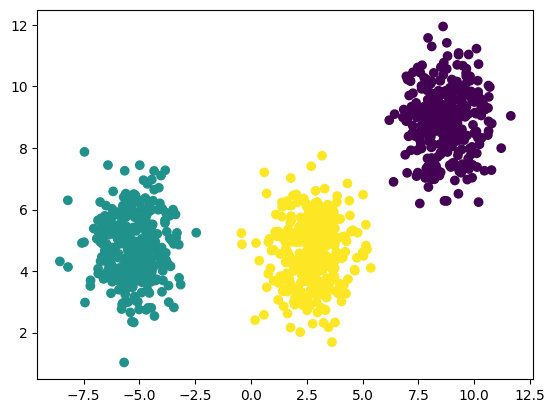

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [7]:
# Standardization for feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [9]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.cluster import KMeans

In [11]:
# Elbow method to select K value
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [12]:
wcss

[1339.9999999999998,
 369.7528809447826,
 161.21119877299245,
 130.17576646840484,
 98.93768153336481,
 68.65099611716613,
 61.95750632371637,
 54.149265996162,
 48.612788073355055,
 40.17075515493049]

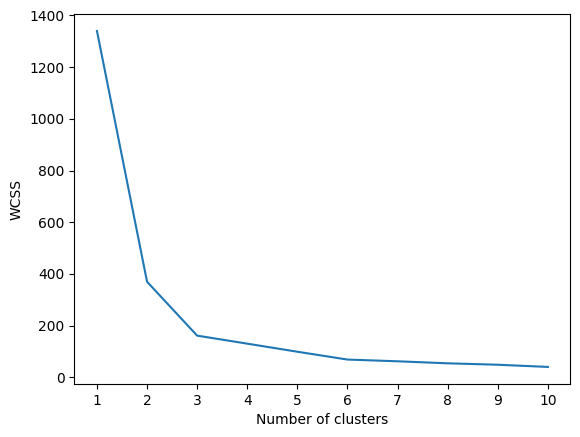

In [13]:
# plot elbow curve
plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

### We determined right value of k using elbow method where our graph bends at a point after which it is stable, like happening in above graph at 3.

In [14]:
kmeans = KMeans(n_clusters=3, init="k-means++")

In [15]:
kmeans.fit_predict(X_train_scaled)

array([1, 1, 2, 0, 1, 2, 2, 2, 0, 1, 2, 2, 2, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       2, 2, 1, 2, 1, 0, 0, 2, 0, 2, 1, 1, 2, 0, 1, 1, 0, 2, 0, 0, 0, 0,
       1, 0, 1, 2, 1, 2, 0, 2, 2, 0, 0, 1, 0, 2, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 2, 0, 0, 1, 1, 2, 2, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 0, 0, 2, 2,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 2, 0, 0,
       1, 1, 1, 0, 2, 2, 1, 1, 0, 2, 0, 0, 1, 0, 0, 2, 0, 1, 0, 0, 2, 2,
       1, 2, 2, 2, 2, 0, 0, 1, 2, 0, 0, 0, 0, 1, 0, 0, 1, 2, 0, 0, 2, 1,
       1, 0, 0, 0, 2, 2, 2, 1, 0, 1, 0, 1, 2, 1, 0, 0, 0, 2, 2, 0, 2, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 2, 1, 1, 2, 0, 2, 2, 0, 1, 0, 1, 2, 2, 1,
       2, 0, 1, 0, 2, 1, 2, 2, 2, 1, 2, 2, 2, 0, 1, 2, 2, 1, 1, 0, 2, 2,
       1, 0, 0, 1, 0, 0, 2, 1, 2, 2, 2, 0, 1, 1, 1, 2, 1, 1, 2, 0, 2, 0,
       1, 2, 2, 2, 2, 1, 2, 1, 1, 2, 0, 2, 0, 0, 2, 0, 2, 1, 1, 1, 0, 1,
       0, 0, 2, 1, 1, 0, 2, 0, 1, 0, 1, 1, 1, 0, 0, 0, 2, 2, 0, 0, 1, 2,
       0, 2, 1, 2, 2, 0, 1, 1, 0, 2, 1, 2, 2, 1, 1,

In [16]:
y_pred = kmeans.predict(X_test_scaled)

In [17]:
y_pred

array([0, 1, 2, 0, 0, 1, 0, 2, 0, 0, 2, 2, 1, 0, 1, 2, 1, 1, 0, 2, 2, 1,
       1, 0, 0, 1, 2, 2, 2, 0, 1, 0, 0, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 1,
       1, 2, 2, 2, 2, 1, 0, 0, 0, 0, 1, 0, 1, 2, 2, 0, 1, 2, 0, 2, 1, 2,
       1, 0, 1, 1, 2, 2, 1, 1, 2, 0, 0, 2, 0, 0, 1, 1, 1, 2, 2, 0, 1, 0,
       0, 2, 1, 2, 2, 0, 0, 0, 1, 2, 2, 2, 0, 1, 1, 2, 2, 2, 2, 1, 0, 0,
       1, 0, 2, 1, 0, 1, 1, 0, 1, 1, 2, 2, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1,
       2, 2, 0, 0, 1, 1, 1, 0, 0, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 0, 2, 2,
       1, 2, 0, 2, 0, 2, 1, 1, 2, 2, 2, 0, 1, 1, 1, 1, 1, 0, 2, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 2, 0, 0, 2, 0, 1, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2,
       0, 0, 2, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 0, 2, 0, 0, 1, 1, 1, 2,
       2, 2, 1, 0, 2, 0, 0, 2, 0, 1, 0, 0, 2, 2, 2, 1, 1, 1, 2, 0, 2, 1,
       2, 2, 1, 1, 2, 0, 1, 1, 0, 1, 2, 1, 0, 2, 2, 2, 2, 1, 2, 2, 0, 1,
       0, 2, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 2, 1, 2, 2, 0, 0, 1, 1, 1,
       2, 0, 2, 1, 2, 1, 2, 2, 1, 0, 1, 1, 2, 0, 0,

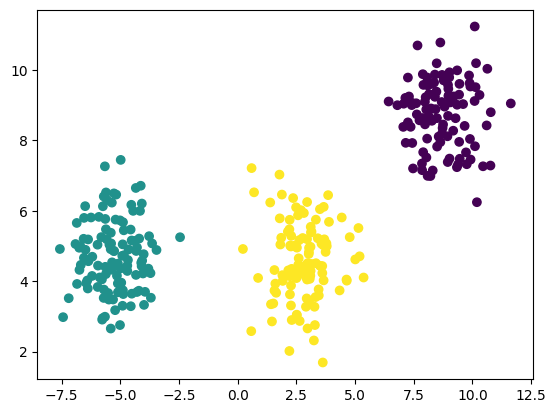

In [18]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)

In [19]:
# validating the k value
# kneelocator
# silhoutee scoring

In [20]:
# kneelocator - need a library named kneed
from kneed import KneeLocator

In [21]:
kl = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')

In [22]:
kl.elbow

np.int64(3)

In [23]:
# silhoutte score
from sklearn.metrics import silhouette_score

In [24]:
silhouette_coefficients = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

In [25]:
silhouette_coefficients

[0.6435629929821116,
 0.647164578424103,
 0.5838660013847529,
 0.500843490764447,
 0.4717116623539889,
 0.46663140037322515,
 0.44874503844323865,
 0.4342516083572351,
 0.38107274314389017]

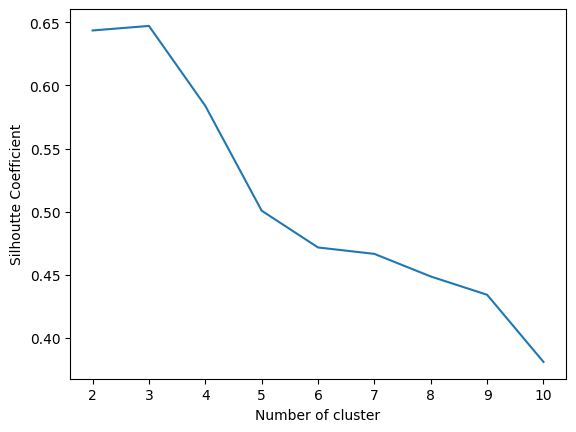

In [26]:
# plotting silhoutte score 
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of cluster")
plt.ylabel("Silhoutte Coefficient")
plt.show()

### Highest silhoutte score (coefficient) can be used as k value which is also 3 here